# Important!
When initially opening the notebook there should be a text to the right of the "Help" menu saying "Changes will not be saved".
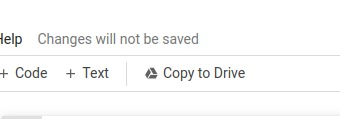

To ensure you can make changes to the notebook save a copy of it to your own drive and work on that one. You can do that by going to "File" -> "Save a copy in Drive".

**Failing to do so will result in code loss!**

 **Note** Make sure you are the only one that has access to it!


In [2]:
#@markdown #Image Processing - 67829. { display-mode: "form" }
#@markdown ##Exercise 5:  Deep Style Image Prior
#@markdown ##Due date: 6.02.2025 at 23:59
#@title{ display-mode: "form" }

#@markdown
#@markdown This exercise is a bit different than the rest of the exercises in the course.
#@markdown The submissions will be a PDF file with your answers and results to the exercise
#@markdown as well as some files so that we can verify the authenticity of your results.
#@markdown This notebook provides the basic code, but you do not need to adhere to some specific API
#@markdown and we will not be running unit tests on your code.
#@markdown We will however, be going over your code and running it manually.
#@markdown Moreover, we will be running tests to ensure the authenticity of your solution and detect plagiarism
#@markdown
#@markdown
#@markdown Before you start working on the exercise it is recommended that you review the lecture slides covering neural networks,
#@markdown
#@markdown
#@markdown **NOTE**: Neural networks are typically trained on GPUs, without GPUs training takes much longer.
#@markdown To enable GPU tranining click on "Runtime" -> "Change runtime type" -> "GPU" -> "SAVE".
#@markdown
#@markdown **NOTE**: A short guide on debugging your code using colab is availble [here](https://colab.research.google.com/github/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/01.06-Errors-and-Debugging.ipynb#scrollTo=qnIn-rWFqoww).

#@markdown But first, we have to download all of the dependencies and install them.
#@markdown Play this cell to download it and get everything ready. markdown This may take a few minutes.


!mkdir impr_ex5_resources
%cd impr_ex5_resources
#!wget "https://www.cs.huji.ac.il/~impr/shape_predictor_68_face_landmarks.dat" -O shape_predictor_68_face_landmarks.dat
#!wget "https://www.cs.huji.ac.il/~impr/align_faces.py" -O align_faces.py
# !wget "https://www.cs.huji.ac.il/w~impr/stylegan2-ada-pytorch.tar" -O stylegan2-ada-pytorch.tar
!wget -v --max-redirect=5 --user-agent="Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"  "https://www.cs.huji.ac.il/w~impr/stylegan2-ada-pytorch.tar" -O stylegan2-ada-pytorch.tar
!tar -xvf stylegan2-ada-pytorch.tar
!rm -f stylegan2-ada-pytorch.tar

import sys
ROOT_PATH="/content/impr_ex5_resources/stylegan2-ada-pytorch"
sys.path.append(ROOT_PATH)


!pip install ninja
!pip install mediapy
CHECKPOINTS_PATH = "https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada/pretrained/ffhq.pkl"



import copy
import os
from time import perf_counter
import click
import imageio
import numpy as np
import PIL.Image
import torch
import torch.nn.functional as F

import dnnlib
import legacy
import numpy as np
from skimage.draw import line
from torch.nn.functional import conv2d,conv1d
import mediapy as media
from IPython.display import clear_output


/content/impr_ex5_resources
--2025-05-12 15:18:25--  https://www.cs.huji.ac.il/w~impr/stylegan2-ada-pytorch.tar
Resolving www.cs.huji.ac.il (www.cs.huji.ac.il)... 128.139.7.26
Connecting to www.cs.huji.ac.il (www.cs.huji.ac.il)|128.139.7.26|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/x-tar]
Saving to: ‘stylegan2-ada-pytorch.tar’

stylegan2-ada-pytor     [  <=>               ]  95.66M   624KB/s    in 2m 42s  

2025-05-12 15:21:08 (606 KB/s) - ‘stylegan2-ada-pytorch.tar’ saved [100311040]

stylegan2-ada-pytorch/
stylegan2-ada-pytorch/metrics/
stylegan2-ada-pytorch/metrics/._precision_recall.py
stylegan2-ada-pytorch/metrics/precision_recall.py
stylegan2-ada-pytorch/metrics/._frechet_inception_distance.py
stylegan2-ada-pytorch/metrics/frechet_inception_distance.py
stylegan2-ada-pytorch/metrics/.___init__.py
stylegan2-ada-pytorch/metrics/__init__.py
stylegan2-ada-pytorch/metrics/._metric_utils.py
stylegan2-ada-pytorch/metrics/metric_uti

# Mounting Google Drive

In [3]:
#@markdown **NOTE**: It is strongly advised you save your results to Google
#@markdown Drive as they will be deleted from Colab once it restarts.
#@markdown To connect Google Drive run this cell.
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


Below is the root dir of your Google Drive. To choose the destenation of the dir to save and read from, create it in your Google Drive and add the relative path to the "GDRIVE_SAVE_REL_PATH" variable below.

In [4]:
ROOT_GDRIVE_PATH="/content/gdrive/MyDrive/"
GDRIVE_SAVE_REL_PATH = "EX5"
FULL_GDRIVE_SAVE_PATH = ROOT_GDRIVE_PATH + GDRIVE_SAVE_REL_PATH

# General Variables

In [5]:
GAUSSIAN_BLUR_DEGRADATION= 'GAUSSIAN_BLUR_DEGRADATION'
GRAYSCALE_DEGRADATION = 'GRAYSCALE_DEGRADATION'
INPAINTING_DEGRADATION = 'INPAINTING_DEGRADATION'
NO_DEGRADATION= 'NO_DEGRADATION'


# Image Alignment

In [20]:
# The align_faces.py script takes in an input image path, an output image path, and a dat file path. The dat file is already downloaded for you, so leave it as it is.
# It is advised that you save the files to google drive as restarting Colab will erase them.
!python "$ROOT_PATH/align_faces/align_faces.py" '/content/drive/My Drive/EX5/evia.jpg' '/content/drive/My Drive/EX5/evia_ali.jpg' "$ROOT_PATH/align_faces/shape_predictor_68_face_landmarks.dat"

Number of faces detected: 1
Detection 0: Left: 44 Top: 80 Right: 151 Bottom: 187
Part 0: (46, 95), Part 1: (44, 110) ...


# Degradation Functions

# GAN Inversion

In [6]:
    # ********************************************************************************************************
    # ******************                   NEED TO ADD DEGRADATION FUNCTIONS                ******************
    # ********************************************************************************************************
import torch
import cv2
import numpy as np

def apply_inpainting(image: torch.Tensor, mask_path: str) -> torch.Tensor:
  _, _, H, W = image.shape
  mask_np = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
  mask_np = mask_np / 255.0
  mask_np = cv2.resize(mask_np, (W, H))
  mask_tensor = torch.tensor(mask_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
  mask_tensor = mask_tensor.repeat(image.shape[0], image.shape[1], 1, 1)
  mask_tensor = mask_tensor.to(image.device)
  return image * mask_tensor

def apply_grayscale(image: torch.Tensor) -> torch.Tensor:
  gray = image.mean(dim=1, keepdim=True)
  return gray.repeat(1, 3, 1, 1)

def apply_gaussian_blur(image: torch.Tensor, kernel_size=15, sigma=5) -> torch.Tensor:
  import torchvision.transforms as T
  blur = T.GaussianBlur(kernel_size=kernel_size, sigma=sigma)
  return blur(image)


In [7]:
losses = []
import matplotlib.pyplot as plt
def plot_optimization_loss(losses, out_path=None):
    """
    Plots the optimization loss curve.

    Args:
        losses (list or np.ndarray): The recorded loss values at each optimization step.
        out_path (str): Optional path to save the plot as an image. If None, the plot is just displayed.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(losses, marker='o', markersize=2, linewidth=1.5)
    plt.xlabel('Optimization Step')
    plt.ylabel('Loss Value')
    plt.title('Optimization Loss Curve')
    plt.grid(True)
    plt.tight_layout()

    if out_path:
        plt.savefig(out_path)
        print(f"Loss plot saved to {out_path}")
    else:
        plt.show()

In [8]:
def run_latent_optimization(outdir,
    degradation_mode,
    G,
    imgs_to_disply_dict,
    target: torch.Tensor, # [C,H,W] and dynamic range [0,255], W & H must match G output resolution
    *,
    num_steps                  = 1000,
    w_avg_samples              = 10000,
    initial_learning_rate      = 0.1,
    initial_noise_factor       = 0.05,
    lr_rampdown_length         = 0.25,
    lr_rampup_length           = 0.05,
    noise_ramp_length          = 0.75,
    regularize_noise_weight    = 1e5,
    latent_dist_reg_weight     = 0.001,
    device: torch.device

):
    assert target.shape == (G.img_channels, G.img_resolution, G.img_resolution)

    G = copy.deepcopy(G).eval().requires_grad_(False).to(device) # type: ignore

    # Compute w stats.
    print(f'Computing W midpoint and stddev using {w_avg_samples} samples...')
    z_samples = np.random.RandomState(123).randn(w_avg_samples, G.z_dim)
    w_samples = G.mapping(torch.from_numpy(z_samples).to(device), None)  # [N, L, C]
    w_samples = w_samples.cpu().numpy().astype(np.float32)
    w_avg = np.mean(w_samples, axis=0, keepdims=True)      # [1, 18, C]
    w_avg_original = torch.from_numpy(w_avg).to(device).float()
    w_std = (np.sum((w_samples - w_avg) ** 2) / w_avg_samples) ** 0.5

    # Setup noise inputs.
    noise_bufs = { name: buf for (name, buf) in G.synthesis.named_buffers() if 'noise_const' in name }

    # Load VGG16 feature detector.
    url = 'https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/metrics/vgg16.pt'
    with dnnlib.util.open_url(url) as f:
        vgg16 = torch.jit.load(f).eval().to(device)

    # Features for target image.
    target_images = target.unsqueeze(0).to(device).to(torch.float32)

    if target_images.shape[2] > 256:
        target_images = F.interpolate(target_images, size=(256, 256), mode='area')
    target_features = vgg16(target_images, resize_images=False, return_lpips=True)

    w_opt = torch.tensor(w_avg, dtype=torch.float32, device=device, requires_grad=True)
    w_out = torch.zeros([num_steps] + list(w_opt.shape[1:]), dtype=torch.float32, device=device)
    optimizer = torch.optim.Adam([w_opt] + list(noise_bufs.values()), betas=(0.9, 0.999), lr=initial_learning_rate)

    # Init noise.
    for buf in noise_bufs.values():
        buf[:] = torch.randn_like(buf)
        buf.requires_grad = True

    for step in range(num_steps):
        # Learning rate schedule.
        t = step / num_steps
        w_noise_scale = w_std * initial_noise_factor * max(0.0, 1.0 - t / noise_ramp_length) ** 2
        lr_ramp = min(1.0, (1.0 - t) / lr_rampdown_length)
        lr_ramp = 0.5 - 0.5 * np.cos(lr_ramp * np.pi)
        lr_ramp = lr_ramp * min(1.0, t / lr_rampup_length)
        lr = initial_learning_rate * lr_ramp
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        # Synth image from opt_w
        w_noise = torch.randn_like(w_opt) * w_noise_scale
        ws = w_opt + w_noise
        synth_images = G.synthesis(ws, noise_mode='const')

        # Prep to save synth image
        synth_image_save = (synth_images + 1) * (255/2)
        synth_image_save = synth_image_save.permute(0, 2, 3, 1).clamp(0, 255).to(torch.uint8)[0].cpu().numpy()


        # ********************************************************************************************************
        # ******************                   NEED TO FILL IN THE FOLLOWING CODE               ******************
        # ********************************************************************************************************
        if degradation_mode == INPAINTING_DEGRADATION:
            synth_images = apply_inpainting(synth_images,"/content/drive/MyDrive/EX5/fei_fei_li_inpainting_mask.png")
        elif degradation_mode == GRAYSCALE_DEGRADATION:
            synth_images = apply_grayscale(synth_images)
        elif degradation_mode == GAUSSIAN_BLUR_DEGRADATION:
            synth_images = apply_gaussian_blur(synth_images)
        # ********************************************************************************************************
        # ******************                          END CODE TO ADD SECTION                   ******************
        # ********************************************************************************************************


        # Prep to save and show images
        synth_image_degraded_save = (synth_images + 1) * (255/2)
        synth_image_degraded_save = synth_image_degraded_save.permute(0, 2, 3, 1).clamp(0, 255).to(torch.uint8)[0].cpu().numpy()

        if step % 20 == 0:
          imgs_to_disply_dict["Generated Image"]=synth_image_save
          imgs_to_disply_dict["Generated Degraded Image"]=synth_image_degraded_save
          clear_output(wait=True)
          media.show_images(imgs_to_disply_dict,height=256)
        if step % 100 == 0:
          PIL.Image.fromarray(synth_image_save, 'RGB').save(f'{outdir}/intermidiate_%d_not_degraded.png'%step)
          PIL.Image.fromarray(synth_image_degraded_save, 'RGB').save(f'{outdir}/intermidiate_%d_degraded.png'%step)


        # Noise regularization.
        reg_loss = 0.0
        for v in noise_bufs.values():
            noise = v[None,None,:,:] # must be [1,1,H,W] for F.avg_pool2d()
            while True:
                reg_loss += (noise*torch.roll(noise, shifts=1, dims=3)).mean()**2
                reg_loss += (noise*torch.roll(noise, shifts=1, dims=2)).mean()**2
                if noise.shape[2] <= 8:
                    break
                noise = F.avg_pool2d(noise, kernel_size=2)

        # Downsample image to 256x256 if it's larger than that. VGG was built for 224x224 images.
        synth_images = (synth_images + 1) * (255/2)
        if synth_images.shape[2] > 256:
            synth_images = F.interpolate(synth_images, size=(256, 256), mode='area')

        # Features for synth images.
        synth_features = vgg16(synth_images, resize_images=False, return_lpips=True)

        # Compute loss
        percep_loss = (target_features - synth_features).square().sum()
        latent_dist_reg = F.l1_loss(w_avg_original, w_opt)
        loss = percep_loss + reg_loss * regularize_noise_weight  + latent_dist_reg_weight * latent_dist_reg
        losses.append(float(loss))

        # Step
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        print(f'step {step+1:>4d}/{num_steps}: percep_loss {percep_loss:<4.2f} latent_dist_reg {latent_dist_reg:<4.2f} loss {float(loss):<5.2f}' )

        # Save inverted latent for each optimization step.
        w_out[step] = w_opt.detach()[0]

        # Normalize noise.
        with torch.no_grad():
            for buf in noise_bufs.values():
                buf -= buf.mean()
                buf *= buf.square().mean().rsqrt()
    return w_out

In [10]:

def invert_image(degradation_mode,
                   target_fname,
                   outdir,
                   seed=303,
                   num_steps=1000,
                   latent_dist_reg_weight=0.001):
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Load networks.
    print('Loading networks from "%s"...' % CHECKPOINTS_PATH)
    device = torch.device('cuda')
    with dnnlib.util.open_url(CHECKPOINTS_PATH) as fp:
        networks = legacy.load_network_pkl(fp)
        G = networks['G_ema'].requires_grad_(False).to(device)


    # Load target image.
    if not os.path.exists(outdir):
      os.makedirs(outdir)
    target_pil = PIL.Image.open(target_fname).convert('RGB')
    w, h = target_pil.size
    s = min(w, h)
    target_pil = target_pil.crop(((w - s) // 2, (h - s) // 2, (w + s) // 2, (h + s) // 2))
    target_pil = target_pil.resize((G.img_resolution, G.img_resolution), PIL.Image.LANCZOS)
    target_uint8 = np.array(target_pil, dtype=np.uint8)
    target=torch.tensor(target_uint8.transpose([2, 0, 1]), device=device),
    target_images = target[0].unsqueeze(0).to(device).to(torch.float32)

    # ********************************************************************************************************
    # ******************                   NEED TO FILL IN THE FOLLOWING CODE               ******************
    # ********************************************************************************************************
    if degradation_mode == INPAINTING_DEGRADATION:
        target_images = apply_inpainting(target_images,"/content/drive/MyDrive/EX5/fei_fei_li_inpainting_mask.png")
    elif degradation_mode == GRAYSCALE_DEGRADATION:
        target_images = apply_grayscale(target_images)
    elif degradation_mode == GAUSSIAN_BLUR_DEGRADATION:
        target_images = apply_gaussian_blur(target_images)
    # ********************************************************************************************************
    # ******************                          END CODE TO ADD SECTION                   ******************
    # ********************************************************************************************************

    #Save target image
    target_to_save = target_images.permute(0, 2, 3, 1).clamp(0, 255).to(torch.uint8)[0].cpu().numpy()
    PIL.Image.fromarray(target_to_save, 'RGB').save(f'{outdir}/original_degraded_image.png')
    imgs_to_disply_dict = {
        "Original Image":target_uint8,
        "Original Degraded Image":target_to_save,
              }

    # Run latent optimization
    start_time = perf_counter()
    optimization_steps = run_latent_optimization(
        outdir,
        degradation_mode,
        G,
        imgs_to_disply_dict,
        target[0],
        num_steps=num_steps,
        device=device,
        latent_dist_reg_weight=latent_dist_reg_weight
    )

    print (f'Elapsed: {(perf_counter()-start_time):.1f} s')
    os.makedirs(outdir, exist_ok=True)

    # Save final inverted image and latent vector.
    inverted_latent = optimization_steps[-1]
    synth_image = G.synthesis(inverted_latent.unsqueeze(0), noise_mode='const')
    synth_image = (synth_image + 1) * (255/2)
    synth_image = synth_image.permute(0, 2, 3, 1).clamp(0, 255).to(torch.uint8)[0].cpu().numpy()
    PIL.Image.fromarray(synth_image, 'RGB').save(f'{outdir}/final_inverted_image.png')
    np.savez(f'{outdir}/inverted_latent.npz', latent=inverted_latent.unsqueeze(0).cpu().numpy())

Original Image,Original Degraded Image,Generated Image,Generated Degraded Image

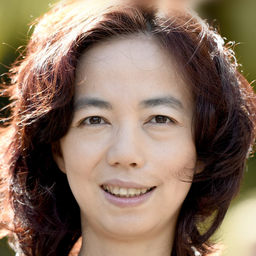
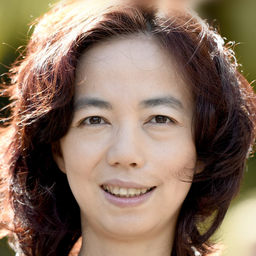
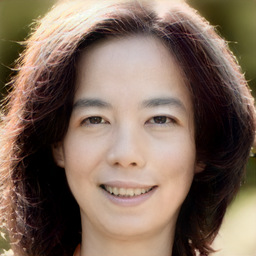
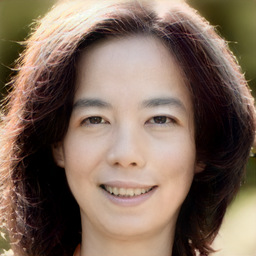

step  481/500: percep_loss 0.19 latent_dist_reg 0.77 loss 0.20 
step  482/500: percep_loss 0.19 latent_dist_reg 0.77 loss 0.20 
step  483/500: percep_loss 0.19 latent_dist_reg 0.77 loss 0.20 
step  484/500: percep_loss 0.19 latent_dist_reg 0.77 loss 0.20 
step  485/500: percep_loss 0.19 latent_dist_reg 0.77 loss 0.20 
step  486/500: percep_loss 0.19 latent_dist_reg 0.77 loss 0.20 
step  487/500: percep_loss 0.19 latent_dist_reg 0.77 loss 0.20 
step  488/500: percep_loss 0.19 latent_dist_reg 0.77 loss 0.20 
step  489/500: percep_loss 0.19 latent_dist_reg 0.77 loss 0.20 
step  490/500: percep_loss 0.19 latent_dist_reg 0.77 loss 0.20 
step  491/500: percep_loss 0.19 latent_dist_reg 0.77 loss 0.20 
step  492/500: percep_loss 0.19 latent_dist_reg 0.77 loss 0.20 
step  493/500: percep_loss 0.19 latent_dist_reg 0.77 loss 0.20 
step  494/500: percep_loss 0.19 latent_dist_reg 0.77 loss 0.20 
step  495/500: percep_loss 0.19 latent_dist_reg 0.77 loss 0.20 
step  496/500: percep_loss 0.19 latent_d

In [30]:
losses = []
invert_image(degradation_mode=NO_DEGRADATION,
             target_fname="/content/drive/MyDrive/EX5/fei_fei_li_original.png",
             outdir="/content/drive/MyDrive/EX5",
                   num_steps=500,
                   latent_dist_reg_weight=0.01)

Loss plot saved to /content/drive/MyDrive/loss_plot_inversion.png


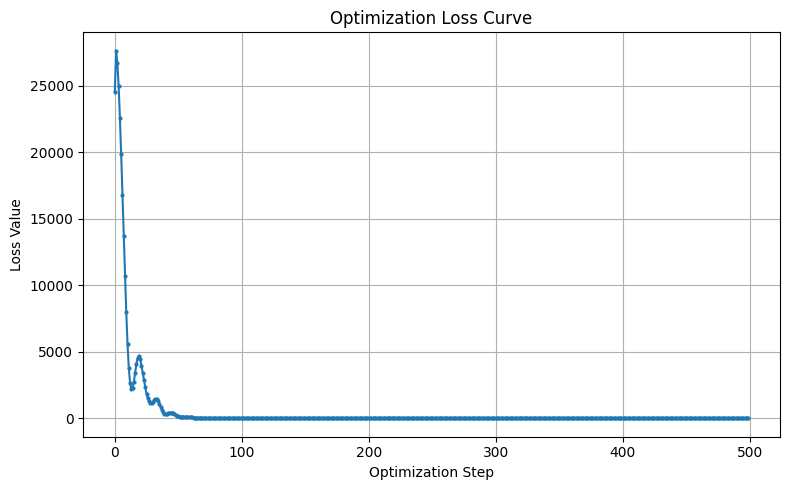

In [32]:
plot_optimization_loss(losses, out_path='/content/drive/MyDrive/loss_plot_inversion.png')

Original Image,Original Degraded Image,Generated Image,Generated Degraded Image

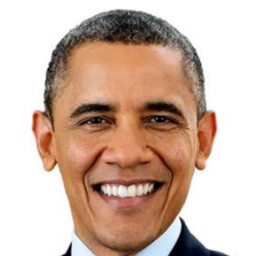
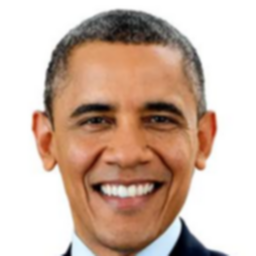
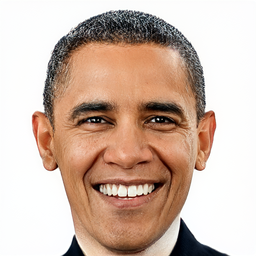
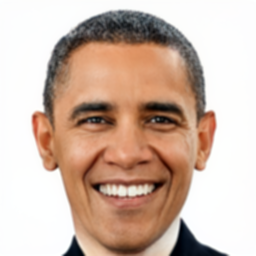

step  681/700: percep_loss 0.08 latent_dist_reg 0.09 loss 0.11 
step  682/700: percep_loss 0.08 latent_dist_reg 0.09 loss 0.11 
step  683/700: percep_loss 0.08 latent_dist_reg 0.09 loss 0.11 
step  684/700: percep_loss 0.08 latent_dist_reg 0.09 loss 0.11 
step  685/700: percep_loss 0.08 latent_dist_reg 0.09 loss 0.11 
step  686/700: percep_loss 0.08 latent_dist_reg 0.09 loss 0.11 
step  687/700: percep_loss 0.08 latent_dist_reg 0.09 loss 0.11 
step  688/700: percep_loss 0.08 latent_dist_reg 0.09 loss 0.11 
step  689/700: percep_loss 0.08 latent_dist_reg 0.09 loss 0.11 
step  690/700: percep_loss 0.08 latent_dist_reg 0.09 loss 0.11 
step  691/700: percep_loss 0.08 latent_dist_reg 0.09 loss 0.11 
step  692/700: percep_loss 0.08 latent_dist_reg 0.09 loss 0.11 
step  693/700: percep_loss 0.08 latent_dist_reg 0.09 loss 0.11 
step  694/700: percep_loss 0.08 latent_dist_reg 0.09 loss 0.11 
step  695/700: percep_loss 0.08 latent_dist_reg 0.09 loss 0.11 
step  696/700: percep_loss 0.08 latent_d

In [48]:
losses = []

invert_image(degradation_mode=GAUSSIAN_BLUR_DEGRADATION,
             target_fname="/content/drive/MyDrive/EX5/obam_ali.png",
             outdir="/content/drive/MyDrive/EX5",
                   num_steps=700,
                   latent_dist_reg_weight=0.35)

Original Image,Original Degraded Image,Generated Image,Generated Degraded Image

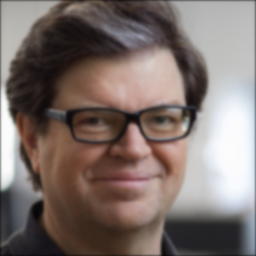
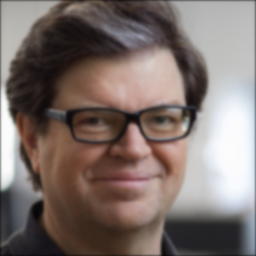
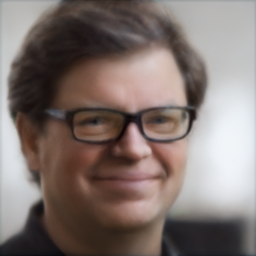
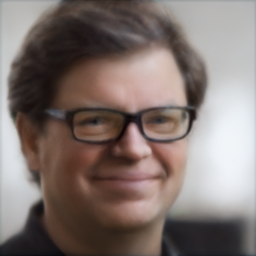

step  981/1000: percep_loss 0.11 latent_dist_reg 0.11 loss 0.18 
step  982/1000: percep_loss 0.11 latent_dist_reg 0.11 loss 0.18 
step  983/1000: percep_loss 0.11 latent_dist_reg 0.11 loss 0.18 
step  984/1000: percep_loss 0.11 latent_dist_reg 0.11 loss 0.18 
step  985/1000: percep_loss 0.11 latent_dist_reg 0.11 loss 0.18 
step  986/1000: percep_loss 0.11 latent_dist_reg 0.11 loss 0.18 
step  987/1000: percep_loss 0.11 latent_dist_reg 0.11 loss 0.18 
step  988/1000: percep_loss 0.11 latent_dist_reg 0.11 loss 0.18 
step  989/1000: percep_loss 0.11 latent_dist_reg 0.11 loss 0.18 
step  990/1000: percep_loss 0.11 latent_dist_reg 0.11 loss 0.18 
step  991/1000: percep_loss 0.11 latent_dist_reg 0.11 loss 0.18 
step  992/1000: percep_loss 0.11 latent_dist_reg 0.11 loss 0.18 
step  993/1000: percep_loss 0.11 latent_dist_reg 0.11 loss 0.18 
step  994/1000: percep_loss 0.11 latent_dist_reg 0.11 loss 0.18 
step  995/1000: percep_loss 0.11 latent_dist_reg 0.11 loss 0.18 
step  996/1000: percep_lo

In [11]:
losses = []
invert_image(degradation_mode=NO_DEGRADATION,
             target_fname="/content/drive/MyDrive/EX5/yann_lecun_blur.png",
             outdir="/content/drive/MyDrive/EX5",
                   num_steps=1000,
                   latent_dist_reg_weight=0.65)

Original Image,Original Degraded Image,Generated Image,Generated Degraded Image

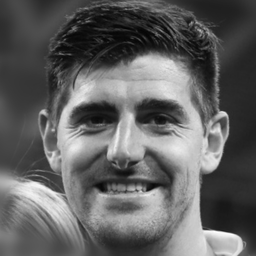
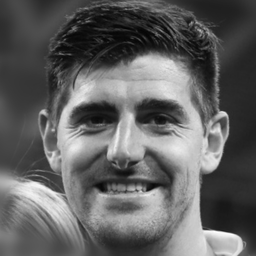
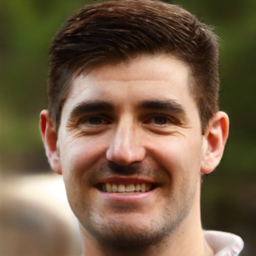
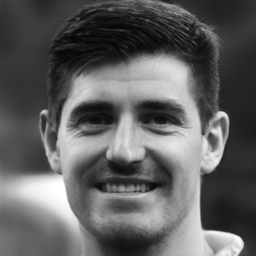

step  681/700: percep_loss 0.18 latent_dist_reg 0.09 loss 0.24 
step  682/700: percep_loss 0.18 latent_dist_reg 0.09 loss 0.24 
step  683/700: percep_loss 0.18 latent_dist_reg 0.09 loss 0.24 
step  684/700: percep_loss 0.18 latent_dist_reg 0.09 loss 0.24 
step  685/700: percep_loss 0.18 latent_dist_reg 0.09 loss 0.24 
step  686/700: percep_loss 0.18 latent_dist_reg 0.09 loss 0.24 
step  687/700: percep_loss 0.18 latent_dist_reg 0.09 loss 0.24 
step  688/700: percep_loss 0.18 latent_dist_reg 0.09 loss 0.24 
step  689/700: percep_loss 0.18 latent_dist_reg 0.09 loss 0.24 
step  690/700: percep_loss 0.18 latent_dist_reg 0.09 loss 0.24 
step  691/700: percep_loss 0.18 latent_dist_reg 0.09 loss 0.24 
step  692/700: percep_loss 0.18 latent_dist_reg 0.09 loss 0.24 
step  693/700: percep_loss 0.18 latent_dist_reg 0.09 loss 0.24 
step  694/700: percep_loss 0.18 latent_dist_reg 0.09 loss 0.24 
step  695/700: percep_loss 0.18 latent_dist_reg 0.09 loss 0.24 
step  696/700: percep_loss 0.18 latent_d

In [39]:
losses = []
invert_image(degradation_mode=GRAYSCALE_DEGRADATION,
             target_fname="/content/drive/MyDrive/cort_gray_ali.png",
             outdir="/content/drive/MyDrive",
                   num_steps=700,
                   latent_dist_reg_weight=0.65)

Original Image,Original Degraded Image,Generated Image,Generated Degraded Image

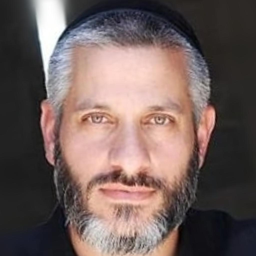
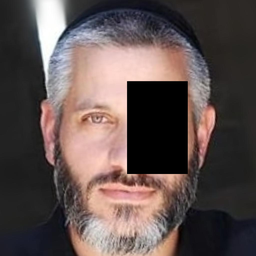
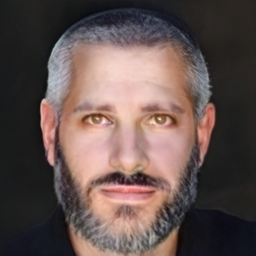
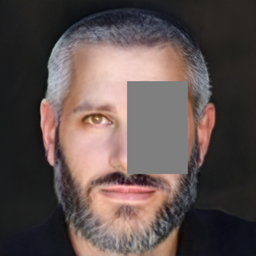

step  381/400: percep_loss 0.25 latent_dist_reg 0.49 loss 0.27 
step  382/400: percep_loss 0.25 latent_dist_reg 0.49 loss 0.27 
step  383/400: percep_loss 0.25 latent_dist_reg 0.49 loss 0.27 
step  384/400: percep_loss 0.25 latent_dist_reg 0.49 loss 0.27 
step  385/400: percep_loss 0.25 latent_dist_reg 0.49 loss 0.27 
step  386/400: percep_loss 0.25 latent_dist_reg 0.49 loss 0.27 
step  387/400: percep_loss 0.25 latent_dist_reg 0.49 loss 0.27 
step  388/400: percep_loss 0.25 latent_dist_reg 0.49 loss 0.27 
step  389/400: percep_loss 0.25 latent_dist_reg 0.49 loss 0.27 
step  390/400: percep_loss 0.25 latent_dist_reg 0.49 loss 0.27 
step  391/400: percep_loss 0.25 latent_dist_reg 0.49 loss 0.27 
step  392/400: percep_loss 0.25 latent_dist_reg 0.49 loss 0.27 
step  393/400: percep_loss 0.25 latent_dist_reg 0.49 loss 0.27 
step  394/400: percep_loss 0.25 latent_dist_reg 0.49 loss 0.27 
step  395/400: percep_loss 0.25 latent_dist_reg 0.49 loss 0.27 
step  396/400: percep_loss 0.25 latent_d

In [21]:
invert_image(degradation_mode=INPAINTING_DEGRADATION,
             target_fname="/content/drive/MyDrive/EX5/evia_ali.jpg",
             outdir="/content/drive/MyDrive/EX5",
                   num_steps=400,
                   latent_dist_reg_weight=0.04)